In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build vocabs
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

In [5]:
block_size = 3 #context length. How many characters are used to predict the next one
X, Y = [], [] #X input to NN, Y is label
for w in words:
    #print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context),'---->', itos[ix])
        context = context[1:] + [ix] # sliding window

X = torch.tensor(X)
Y = torch.tensor(Y)    

In [6]:
X.shape

torch.Size([228146, 3])

In [7]:
def build_dataset(words):

    block_size = 3 #context length. How many characters are used to predict the next one
    X, Y = [], [] #X input to NN, Y is label
    for w in words:
        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context),'---->', itos[ix])
            context = context[1:] + [ix] # sliding window

    X = torch.tensor(X)
    Y = torch.tensor(Y)    
    return X, Y


import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [8]:
C = torch.randn((27,2)) # randomly initialised matrix of embeddings. We embed each letter with a 2x1 vector

In [9]:
print(itos[5])
C[5] # 2d embedding of e

e


tensor([0.4245, 1.7682])

In [10]:
F.one_hot(torch.tensor(5), num_classes=27).float()

tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [11]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C # different way to index. Works because of matrix multiplication 

tensor([0.4245, 1.7682])

In [12]:
emb = C[X] # for every number in X array, grab the 1x2 embedding
emb.shape # the example (e.g. ..e), the letter, the embedding of that letter

torch.Size([228146, 3, 2])

In [13]:
W1 = torch.randn((6, 100)) # 6 as we have a block_size of 3 and embedding length of 2
b1 = torch.randn(100)

In [14]:
torch.unbind(emb, 1)[0][31][1]

# emb has shape 32, 3, 2.

# unbind on the 1st index so the 3. That means we get a tuples of 3 tensors, each with shape 32,2


tensor(0.6479)

In [15]:
# Concatenate the tuple of 3 (32x2) tensor into a 32 x 6 tensor
# (32, 2)
# (32, 2)
# (32, 2)
#      ↓ cat along dim=1
# (32, 6)

torch.cat(torch.unbind(emb, 1), 1).shape 

torch.Size([228146, 6])

In [16]:
emb.view(-1, 6) == torch.cat(torch.unbind(emb, 1), 1) # in efficient way and creates new memory

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        ...,
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True]])

In [17]:
h = torch.tanh(emb.view(emb.shape[0],6) @ W1 + b1)

In [18]:
(emb.view(emb.shape[0],6) @ W1).shape

torch.Size([228146, 100])

In [19]:
b1.shape

torch.Size([100])

In [20]:
# broadcasting aligns on the right. Either the numbers must be equal OR one must be 1 OR one must be 0
# so we can broadcast b1

In [21]:
W2 = torch.randn(100,27)
b2 = torch.randn(27)

In [22]:
logits = h @ W2 + b2
logits.shape

torch.Size([228146, 27])

In [23]:
counts = logits.exp()
prob = counts / counts.sum(dim=1, keepdim=True) # dim=1 as we are summing across the columns for each row. 
print(counts.sum(dim=1, keepdim=False).shape) # Keepdims = True as this keeps the right shape for broadcasting fules
print(counts.sum(dim=1, keepdim=True).shape) 
print(f"prob shape: {prob.shape}")

torch.Size([228146])
torch.Size([228146, 1])
prob shape: torch.Size([228146, 27])


In [24]:
#nll = -prob[torch.arange(-1), Y].log().mean() # negative log likelihood. 
#nll

In [25]:
# ------- Clean up -------

In [26]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([182625, 3]), torch.Size([182625]))

In [27]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn(200,27, generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]


In [28]:
sum(p.nelement() for p in parameters)

11897

In [29]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1,30) @ W1 + b1) # 32, 100
logits = h @ W2 + b2 # 32, 27
#counts = logits.exp()
#prob = counts / counts.sum(dim=1, keepdim=True)
#loss = -prob[torch.arange(32), Y].log().mean()
#loss
loss = F.cross_entropy(logits, Ytr) # cross entropy is exactly the same as what we did before. Avoids floating point issues with the .exp() for large numbers.
# pytorch subtracts max. Low numbers are fine, high numbers cause infs.
loss

tensor(26.0047)

In [30]:
for p in parameters:
    p.requires_grad = True

In [31]:
# learning rates to find optimal
# often you do a learning rate decay. E.g. train your modle with the optimal one, then lower it
lre = torch.linspace(-3,0,1000) # 1000 nums between -3 and 0
lrs = 10 ** lre

In [32]:
lri = []
lossi = []
stepi = []

In [44]:
for i in range(50000):

    # mini-batch construct
    # better to do more steps with less accurate gradient
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,30) @ W1 + b1) 
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    #print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None

    loss.backward()

    # update
    #lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    #lri.append(lre[i])
    lossi.append(loss.log10().item())
    stepi.append(i)

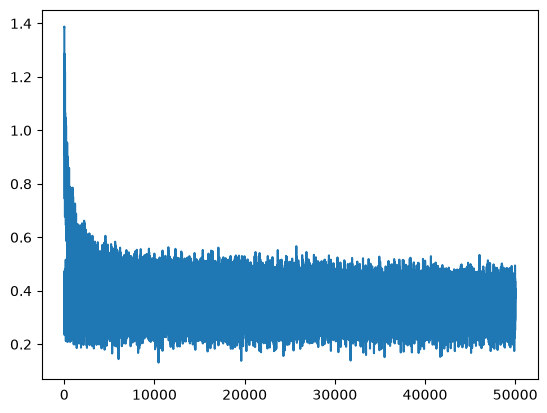

In [45]:
plt.plot(stepi,lossi) # noise due to training with mini batches

In [46]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,30) @ W1 + b1) 
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss # low training set loss can be due to overfitting. i.e model has just 'remembered' training data. # test on different set we trained on. 

tensor(2.1537, grad_fn=<NllLossBackward0>)

In [47]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,30) @ W1 + b1) 
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss # low training set loss can be due to overfitting. i.e model has just 'remembered' training data. # test on different set we trained on. 

tensor(2.1885, grad_fn=<NllLossBackward0>)

In [36]:
# split data into 3: training split, dev/validation split, test split
# 80%, 10%, 10%

# training finds parameters
# dev/validation trains hyper parameters (e.g. of embedding or number of neurons)
# test is for model at the end once its trained

# if training loss = dev loss then we are underfitting.


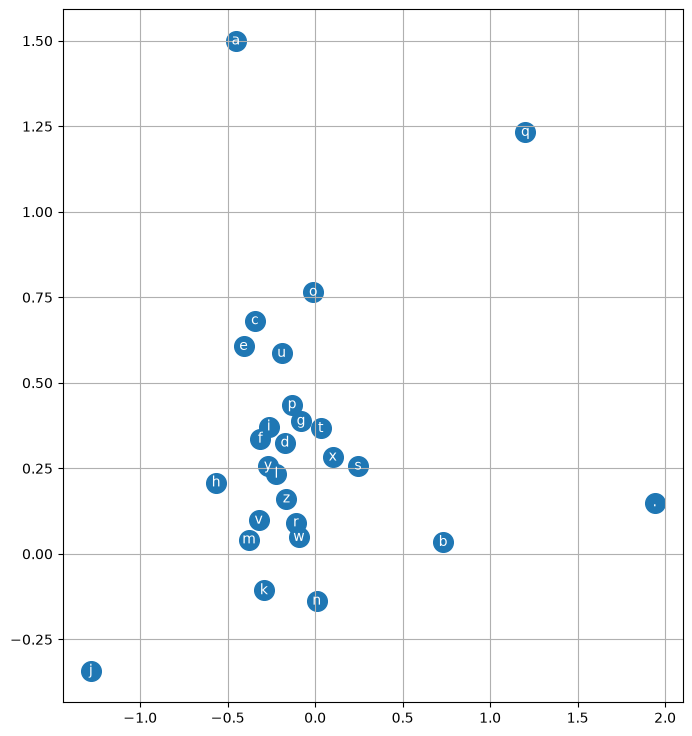

In [37]:
plt.figure(figsize=(8,9))
plt.scatter(C[:,0].data,C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item() ,C[i,1].item(), itos[i], ha="center", va="center", color="white")
plt.grid('minor')

In [48]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carpahfaal.
havi.
kimleigentleenanden.
jazontefameryst.
kaeli.
nellara.
chaiiv.
kaleigh.
ham.
jord.
quinn.
saline.
liveni.
wazelo.
dearynix.
kaelynn.
abee.
deci.
abetteley.
frana.
